In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
data=pd.read_csv("/content/marketing_campaign.csv",sep="\t")
print("Numbers of datapoints:",len(data))
data.head()

Numbers of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [27]:
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [28]:
data.duplicated().sum()

np.int64(0)

In [29]:
data["Income"]=data["Income"].fillna(data["Income"].median())

In [30]:
data["Income"].isnull().sum()

np.int64(0)

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [32]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format="mixed", dayfirst=True)

In [33]:
data["Age"]=2021 - data["Year_Birth"]

In [34]:
data["Spent"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]

In [35]:
data["Living_With"]=data["Marital_Status"].replace({"Married":"Patner","Together":"Partner","Absurd":"Alone","Widow":"Alone","YOLO":"Alone","Divorced":"Alone","Single":"Alone"})

In [36]:
print(data.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Spent', 'Living_With']


In [37]:
print([c for c in data.columns if "child" in c.lower() or "living" in c.lower()])

['Living_With']


In [38]:
data['Living_With'].unique()

array(['Alone', 'Partner', 'Patner'], dtype=object)

In [39]:
data["Living_With"] = data["Living_With"].replace({"Patner":"Partner"})

In [40]:
data["Education"] = data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate","Graduation":"Graduate","Master":"Postgraduate","PhD":"Postgraduate"})

In [41]:
data = data.rename(columns={"MntWines":"Wines", "MntFruits":"Fruits", "MntMeatProducts":"Meat", "MntFishProducts":"Fish", "MntSweetProducts":"Sweets", "MntGoldProds":"Gold"})

In [42]:
to_drop = ["Marital_Status","Dt_Customer","Z_CostContact","Z_Revenue","Year_Birth","ID"]
data = data.drop(to_drop,axis=1)

In [43]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spent
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,52.194196,605.798214
std,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,11.984069,602.249288
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,5.000000
25%,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44.000000,68.750000
50%,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,396.000000
75%,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,62.000000,1045.500000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,128.000000,2525.000000


In [44]:
data.select_dtypes(include="object").columns

Index(['Education', 'Living_With'], dtype='object')

In [45]:
data = pd.get_dummies(data,columns=["Education","Living_With"], dtype=int)

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler= StandardScaler()
data_scaled = scaler.fit_transform(data)

In [48]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [49]:
from sklearn.decomposition import PCA

In [50]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

In [51]:
from sklearn.cluster import KMeans

In [52]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_pca)

In [53]:
data["Cluster"] = clusters

In [54]:
data["Cluster"].value_counts()

,count
Cluster,
1,767
2,507
0,499
3,467


In [55]:
from sklearn.metrics import silhouette_score
silhouette_score(data_pca, clusters)

np.float64(0.4017973486420698)

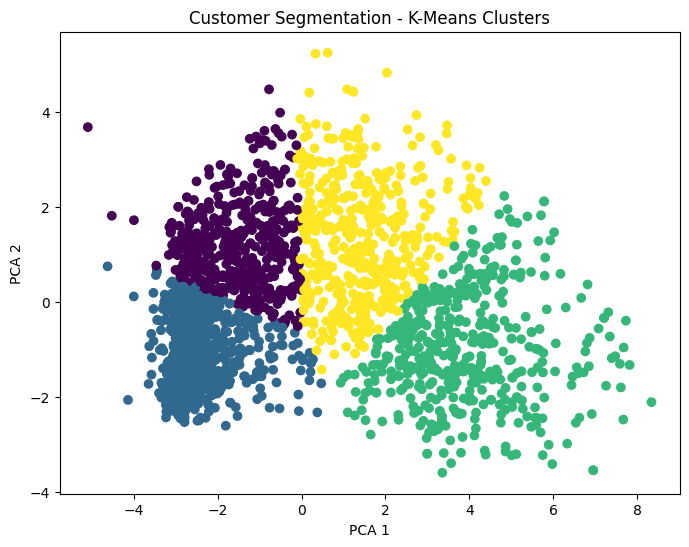

In [56]:
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation - K-Means Clusters")
plt.show()

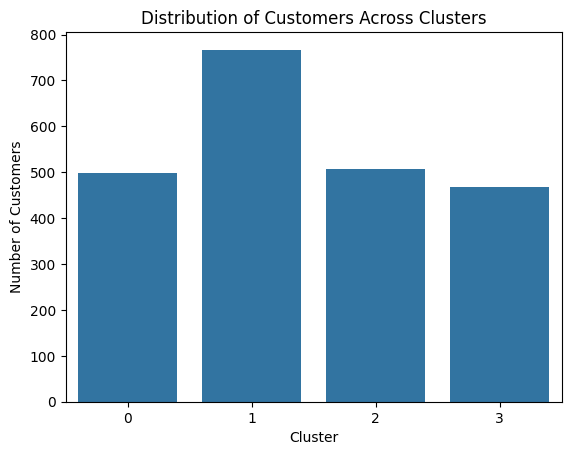

In [57]:
sns.countplot(x=data["Cluster"])
plt.title("Distribution of Customers Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

In [58]:
cluster_profile = data.groupby("Cluster").mean(numeric_only=True)
print(cluster_profile)

               Income   Kidhome  Teenhome    Recency       Wines     Fruits  \
Cluster                                                                       
0        46483.246493  0.581162  0.881764  46.707415  162.036072   6.038076   
1        32275.226858  0.823990  0.303781  50.505867   29.520209   6.397653   
2        77368.394477  0.043393  0.167653  50.443787  602.445759  73.573964   
3        63890.899358  0.109208  0.805139  47.933619  582.179872  29.325482   

               Meat        Fish     Sweets       Gold  ...  AcceptedCmp2  \
Cluster                                                ...                 
0         50.567134    8.801603   5.603206  26.549098  ...      0.004008   
1         22.852673    9.606258   6.376793  17.092568  ...      0.000000   
2        473.672584  105.818540  75.621302  83.822485  ...      0.029586   
3        194.978587   39.929336  31.250535  63.710921  ...      0.027837   

         Complain  Response        Age        Spent  Education_Gradu

In [61]:
cluster_profile[["Income", "Childern", "Age", "Spent", "Is_Parent"]]

KeyError: "['Childern', 'Is_Parent'] not in index"

In [62]:
from sklearn.cluster import AgglomerativeClustering

In [63]:
agg = AgglomerativeClustering(n_clusters=4)
agg_clusters = agg.fit_predict(data_pca)

print("Agglomerative Clustering completed")

Agglomerative Clustering completed


In [65]:
from sklearn.metrics import silhouette_score

agg_score = silhouette_score(data_pca, agg_clusters)
print("Agglomerative Silhouette Score:",agg_score)

Agglomerative Silhouette Score: 0.36340344946173664


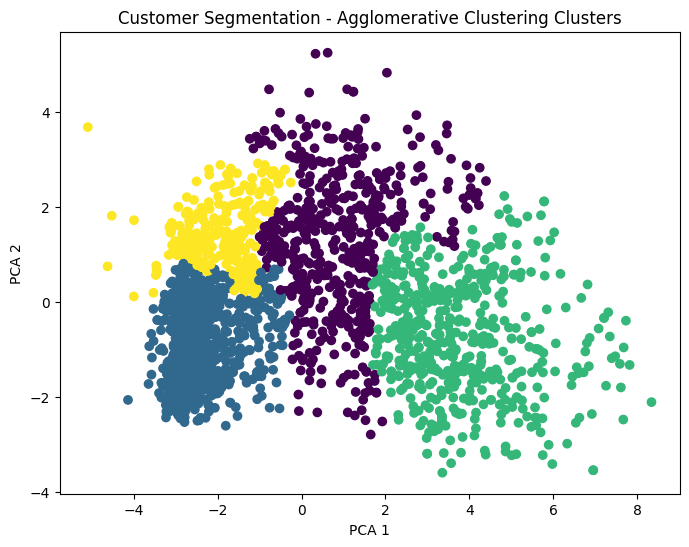

In [66]:
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=agg_clusters, cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation - Agglomerative Clustering Clusters")
plt.show()

In [67]:
print("K-Means Silhouette Score:",0.4362)
print("Agglomerative Silhouette Score:",agg_score)

K-Means Silhouette Score: 0.4362
Agglomerative Silhouette Score: 0.36340344946173664


CONCLUSION

K-Means and Agglomerative Clustering were used to segment customers into 4 groups based on their characterstics.



The K-Means silhouette Score was 0.4362, while  the Agglomerative clustering Silhouette Score was 0.3634.


Both algorithms produced meaningful customer segments ,and their results were compared using the Silhouette Score and visualizations.


The customer segments can help businesses understand different customer profiles and support targeted marketing strategies.